# AeroVision: Analisis Komparatif Seluruh Tahap Preprocessing (Stage 0 s.d Stage 7)
## Nama Anggota
- F1D02410134 : RINALDI NOVIYANTO
- F1D02410053 : I NYOMAN WIDIYASA JAYANANDA
- F1D02410030 : ZUNNUN QORINA
- F1D02410092 : SABRINA MAWADATHUN SALSABILA


### Impor Pustaka & Inisialisasi Lingkungan (5W + 1H)
- **What (Apa)**: Melakukan impor library Python (NumPy, Pandas, OpenCV, Sklearn, Matplotlib, Joblib) dan modul akselerasi hardware internal.
- **Why (Mengapa)**: Menyediakan dependensi runtime yang dibutuhkan dan secara otomatis mengklon repositori serta memasang library jika dijalankan di Google Colab.
- **Who (Siapa)**: Dijalankan oleh environment kernel (Python 3) atas instruksi dari user/pengembang.
- **Where (Di mana)**: Dijalankan di tingkat teratas workspace memori kernel notebook.
- **When (Kapan)**: Dieksekusi di awal runtime sebagai langkah pertama sebelum proses komputasi dimulai.
- **How (Bagaimana)**: Menggunakan pendeteksian sys.modules dan perintah os.environ serta pip install untuk setup environment.


In [7]:
# Import library yang kalian butuhkan
import sys
import os
import importlib

# 1. Force PyTorch to initialize its CUDA context FIRST before CuPy starts
try:
    import torch
    if torch.cuda.is_available():
        _ = torch.randn(1, device='cuda') @ torch.randn(1, device='cuda')
        print('[PyTorch] Native GPU (CUDA) successfully initialized first!')
except Exception as e:
    pass

# Auto-detect environment
try:
    IS_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())
except NameError:
    IS_COLAB = False

if IS_COLAB:
    # Auto-setup for Google Colab if files are missing
    if not os.path.exists('all-script-accelerated.py') or not os.path.exists('fgvc-aircraft'):
        print("Running on Google Colab. Auto-setting up directory and installing packages...")
        # Clone the github repository
        get_ipython().system('git clone https://github.com/Schryzon/AeroVision.git')
        # Move repository files into the main working directory
        get_ipython().system('mv AeroVision/* .')
        get_ipython().system('mv AeroVision/.[!.]* . 2>/dev/null || true')
        # Install dependencies
        get_ipython().system('pip install -r requirements.txt')
        print("Colab environment setup complete!")

import numpy as np
import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Setup parent path so we can import the local all-script-accelerated module
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
acc = importlib.import_module('all-script-accelerated')

# Display GPU status
acc.gpu_info()


💤 GPU not available — using NumPy (CPU)


#### Analisis & Penjelasan Belakang Layar (Behind the Scenes)
---
Sel pertama ini memuat pustaka dasar Python untuk komputasi (NumPy, Pandas), pemrosesan gambar (OpenCV), visualisasi (Matplotlib, Seaborn), penyimpanan model (Joblib), evaluasi (Scikit-Learn), serta modul akselerasi perangkat keras khusus `all-script-accelerated.py` (diimpor sebagai `acc`).

**Di Balik Layar (Behind the Scenes):**
Saat skrip `all-script-accelerated.py` diimpor, skrip tersebut secara otomatis mendeteksi lingkungan runtime. Jika dijalankan di Google Colab, sel ini akan mengklon repositori GitHub AeroVision dan memasang dependensi secara otomatis jika terdeteksi ada file yang kurang. Melalui fungsi `acc.gpu_info()`, modul `all-script-accelerated` memanggil fungsi pemeriksaan backend `gpu_available()` dan memeriksa ketersediaan CuPy (`import cupy as cp`). Jika modul CuPy terpasang dan GPU NVIDIA terdeteksi, program akan mencetak status nama GPU beserta jumlah VRAM yang tersedia, dan mengaktifkan mode *smart dispatch* (akselerasi otomatis untuk citra dengan resolusi $\ge 256 \times 256$ piksel). Jika tidak ada GPU, program secara otomatis melakukan fallback ke CPU menggunakan NumPy.


## I. Pemuatan Data


Buat struktur folder dataset sebagai berikut:
```
.
└──dataset
    ├── label1
	├── image1.jpg
	├── image2.jpg
	└── image3.jpg
    ├── label2
    └── label3
    └── dst...
```


### Pengorganisasian Data dan Pemuatan Citra (5W + 1H)
- **What (Apa)**: Menggabungkan metadata CSV dari dataset FGVC-Aircraft, membuat subdirektori kelas pesawat, menyalin/symlink gambar, dan memuatnya ke memori dengan resize 256x256.
- **Why (Mengapa)**: Untuk menyusun struktur data folder yang rapi dan memuat data citra ke dalam array biner yang siap diolah secara seragam.
- **Who (Siapa)**: Modul manajemen dataset mengorganisasi file, sedangkan pengembang memilih mode klasifikasi (diverse subset vs full).
- **Where (Di mana)**: Membaca file gambar asli dari folder fgvc-aircraft dan mengorganisasikannya ke folder dataset/ lalu memuatnya ke memori RAM.
- **When (Kapan)**: Dijalankan setelah inisialisasi library selesai dan sebelum augmentasi atau preprocessing.
- **How (Bagaimana)**: Menggunakan pandas.concat untuk merging CSV, os.symlink/shutil.copy2 untuk organisasi folder, dan cv.imread serta acc.resize untuk memuat citra.


In [8]:
import os
import shutil
import cv2 as cv
import numpy as np
import pandas as pd

try:
    IS_COLAB = 'COLAB_GPU' in os.environ or 'google.colab' in str(get_ipython())
except NameError:
    IS_COLAB = False

# Google Drive integration for Google Colab
if IS_COLAB:
    if not os.path.exists('/content/drive'):
        print("Mounting Google Drive to access the dataset...")
        try:
            from google.colab import drive
            drive.mount('/content/drive')
        except Exception as e:
            print("Google Drive mount failed:", e)

csv_paths = [
    'fgvc-aircraft/train.csv',
    'fgvc-aircraft/val.csv',
    'fgvc-aircraft/test.csv'
]

# Read and merge all 3 CSVs
df_list = []
for path in csv_paths:
    if os.path.exists(path):
        df_list.append(pd.read_csv(path))
    else:
        colab_path = os.path.join('/content', path)
        drive_path = os.path.join('/content/drive/MyDrive', path)
        if os.path.exists(colab_path):
            df_list.append(pd.read_csv(colab_path))
        elif os.path.exists(drive_path):
            df_list.append(pd.read_csv(drive_path))

if len(df_list) == 0:
    raise FileNotFoundError("Could not find any fgvc-aircraft CSV files (train.csv, val.csv, test.csv).")

df_merged = pd.concat(df_list, ignore_index=True)
print(f"Total merged CSV entries: {len(df_merged)}")

src_images_dir = 'fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/'
dst_dataset_dir = 'dataset/'

if not os.path.exists(src_images_dir):
    # Try Google Drive path first, then local Colab clone folder
    drive_images_dir = '/content/drive/MyDrive/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/'
    colab_images_dir = '/content/fgvc-aircraft/fgvc-aircraft-2013b/fgvc-aircraft-2013b/data/images/'
    
    if os.path.exists(drive_images_dir):
        src_images_dir = drive_images_dir
    elif os.path.exists(colab_images_dir):
        src_images_dir = colab_images_dir

if not os.path.exists(src_images_dir):
    print("\n[!] DATASET IMAGES NOT FOUND.")
    print("Please upload your 'fgvc-aircraft-2013b' directory to Colab, or place it in Google Drive under:")
    print("  'My Drive/fgvc-aircraft/fgvc-aircraft-2013b/'")
    raise FileNotFoundError(f"Source images directory not found at: {src_images_dir}")

os.makedirs(dst_dataset_dir, exist_ok=True)

success_count = 0
symlink_count = 0
copy_count = 0

print("Organizing dataset folders...")
for index, row in df_merged.iterrows():
    img_name = row['filename']
    class_name = str(row['Classes']).strip().replace('/', '-').replace('\\', '-')
    
    class_dir = os.path.join(dst_dataset_dir, class_name)
    os.makedirs(class_dir, exist_ok=True)
    # Ensure .gitkeep is present
    with open(os.path.join(class_dir, '.gitkeep'), 'w') as keep_f:
        pass
    
    src_file = os.path.join(src_images_dir, img_name)
    dst_file = os.path.join(class_dir, img_name)
    
    if os.path.exists(dst_file):
        success_count += 1
        continue
        
    if not os.path.exists(src_file):
        continue
        
    if not IS_COLAB:
        try:
            os.symlink(os.path.abspath(src_file), os.path.abspath(dst_file))
            symlink_count += 1
            success_count += 1
            continue
        except Exception:
            pass  # Fallback to copy if symlinks are not allowed (no admin privileges)
            
    shutil.copy2(src_file, dst_file)
    copy_count += 1
    success_count += 1

print(f"Dataset organized! Total: {success_count} (Symlink: {symlink_count}, Copy: {copy_count})")

# We use a diverse subset of 10 commercial aircraft classes (1,000 images total, 3,000 augmented)
CLASSIFICATION_MODE = 'diverse_subset'
diverse_classes = {
    'A380', 'ATR-72', 'Fokker 100', 'MD-11', 'Cessna 172',
    '747-400', '737-800', 'BAE 146-200', 'DHC-6', 'E-190'
}

CACHE_DIR = 'cache'
DEFAULT_CACHE_FILE = os.path.join(CACHE_DIR, 'data_cache.npz')
CACHE_KEYS = {'data', 'labels', 'file_name', 'data_all', 'labels_all'}

os.makedirs(CACHE_DIR, exist_ok=True)

def find_dataset_cache(cache_dir):
    if not os.path.isdir(cache_dir):
        return None

    cache_paths = [
        os.path.join(cache_dir, filename)
        for filename in os.listdir(cache_dir)
        if filename.endswith('.npz')
    ]
    preferred_names = ('data_cache.npz', 'data_cahce.npz')

    for preferred_name in preferred_names:
        preferred_path = os.path.join(cache_dir, preferred_name)
        if preferred_path in cache_paths:
            return preferred_path

    if len(cache_paths) == 0:
        return None

    return max(cache_paths, key=os.path.getmtime)

def validate_dataset_cache(cache_path, cache):
    missing_keys = CACHE_KEYS.difference(cache.files)
    if missing_keys:
        raise KeyError(f'Missing keys: {sorted(missing_keys)}')

    cached_data = cache['data']
    cached_labels = cache['labels']
    cached_file_name = cache['file_name']
    cached_data_all = cache['data_all']
    cached_labels_all = cache['labels_all']

    if cached_data.ndim != 3 or cached_data.shape[1:] != (256, 256):
        raise ValueError(f'Invalid data shape: {cached_data.shape}')
    if cached_data_all.ndim != 3 or cached_data_all.shape[1:] != (256, 256):
        raise ValueError(f'Invalid data_all shape: {cached_data_all.shape}')
    if len(cached_labels) != len(cached_data):
        raise ValueError('labels length does not match data length')
    if len(cached_file_name) != len(cached_data):
        raise ValueError('file_name length does not match data length')
    if len(cached_labels_all) != len(cached_data_all):
        raise ValueError('labels_all length does not match data_all length')

    print(f'Cache verified: {cache_path}')
    return cached_data, cached_labels, cached_file_name, cached_data_all, cached_labels_all

cache_file = find_dataset_cache(CACHE_DIR)
cache_loaded = False

if cache_file is not None:
    cache = None
    try:
        print(f'Loading resized image cache from {cache_file}...')
        cache = np.load(cache_file, allow_pickle=True)
        data, labels, file_name, data_all, labels_all = validate_dataset_cache(cache_file, cache)
        cache_loaded = True
    except Exception as e:
        print(f'[Cache] Could not use {cache_file}: {e}')
        print('[Cache] Regenerating resized image cache from dataset files...')
    finally:
        if cache is not None:
            cache.close()

if not cache_loaded:
    data = []
    labels = []
    file_name = []

    data_all = []
    labels_all = []

    print("Loading and resizing images to 256x256...")
    sub_folders = os.listdir(dst_dataset_dir)
    for sub_folder in sub_folders:
        sub_folder_path = os.path.join(dst_dataset_dir, sub_folder)
        if not os.path.isdir(sub_folder_path):
            continue
            
        sub_folder_files = os.listdir(sub_folder_path)
        for filename in sub_folder_files:
            if filename == '.gitkeep':
                continue
            img_path = os.path.join(sub_folder_path, filename)
            img = cv.imread(img_path)
            if img is None:
                continue
            img = img.astype(np.uint8)
            img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
            
            # Native CPU resize to 256x256 is extremely fast and avoids GPU copy overhead
            img = cv.resize(img, (256, 256), interpolation=cv.INTER_LINEAR)
            img_cpu = img
            
            # Load for CNN (all 100 classes)
            data_all.append(img_cpu)
            labels_all.append(sub_folder)
            
            # Load for Traditional ML (only diverse subset)
            if sub_folder in diverse_classes:
                data.append(img_cpu)
                labels.append(sub_folder)
                file_name.append(filename)

    data = np.array(data)
    labels = np.array(labels)
    file_name = np.array(file_name)
    data_all = np.array(data_all)
    labels_all = np.array(labels_all)

    np.savez_compressed(
        DEFAULT_CACHE_FILE,
        data=data,
        labels=labels,
        file_name=file_name,
        data_all=data_all,
        labels_all=labels_all
    )
    print(f'Resized image cache saved to {DEFAULT_CACHE_FILE}')

print(f"Successfully loaded {len(data)} images for Traditional ML (10 classes).")
print(f"Successfully loaded {len(data_all)} images for CNN (100 classes).")


Total merged CSV entries: 10000
Organizing dataset folders...
Dataset organized! Total: 10000 (Symlink: 0, Copy: 0)
Loading resized image cache from cache\data_cache.npz...
Cache verified: cache\data_cache.npz
Successfully loaded 1000 images for Traditional ML (10 classes).
Successfully loaded 10000 images for CNN (100 classes).


#### Analisis & Penjelasan Belakang Layar (Behind the Scenes)
---
Sel ini membaca file CSV pengelompokan gambar pesawat FGVC-Aircraft, menggabungkan data training/validation/testing, menyalin atau membuat symlink file gambar ke folder `dataset/` berdasarkan sub-folder nama kelasnya, lalu memuat citra ke memori sebagai array grayscale dengan resolusi seragam $256 \times 256$. Jika cache `.npz` sudah tersedia di folder `cache/`, sel ini langsung memuat array hasil resize tersebut agar setiap stage bisa mulai dari data siap pakai.

**Di Balik Layar (Behind the Scenes):**
Pemuatan gambar menggunakan `cv.imread` untuk membaca citra keabuan. Ukuran gambar kemudian diseragamkan dengan memanggil fungsi `cv.resize` untuk menghindari *PCIe transfer overhead*. Hasil resize disimpan otomatis ke `cache/data_cache.npz` jika cache belum ada. Jika cache yang ditemukan rusak, tidak lengkap, atau bentuk datanya tidak cocok, cache tersebut diabaikan dan dibuat ulang dari file dataset.

Untuk kompatibilitas memori, hasil pemrosesan dibungkus menggunakan `acc.to_cpu(img)` yang mengembalikan array NumPy standar. Parameter `CLASSIFICATION_MODE = 'diverse_subset'` membatasi analisis pada 10 kelas pesawat komersial yang bervariasi (misalnya `Boeing 737-800`, `Boeing 747-400`, `A380`, `ATR-72`, dll.). Hal ini memberikan variabilitas struktural tekstur (sayap, ekor, propeller, propeller jet, badan ganda) yang sangat kaya bagi model klasifikasi tekstur GLCM.


## II. Augmentasi Data


### Definisi Fungsi Augmentasi


### Iterasi Augmentasi Data (5W + 1H)
- **What (Apa)**: Menerapkan transformasi geometri berupa pembalikan horizontal (horizontal flip) dan rotasi 15 derajat CCW.
- **Why (Mengapa)**: Untuk memperbanyak jumlah sampel gambar secara buatan (artificial) agar variasi orientasi objek melatih model untuk lebih generalis (mencegah overfitting).
- **Who (Siapa)**: Modul augmentasi data memproses matriks citra input.
- **Where (Di mana)**: Operasi dilakukan di dalam memori RAM/GPU dengan menduplikasi array data gambar.
- **When (Kapan)**: Dieksekusi setelah dataset dimuat seluruhnya ke memori, sebelum alur preprocessing dimulai.
- **How (Bagaimana)**: Menggunakan fungsi acc.Image_Ops.flip and acc.Image_Ops.rotate yang di-resize kembali ke 256x256 untuk menjaga dimensi.


In [9]:
# melakukan augmentasi data
data_augmented = []
labels_augmented = []
file_name_augmented = []

print("Augmenting data using GPU-accelerated operations...")
for i in range(len(data)):
    img = data[i]
    lbl = labels[i]
    fname = file_name[i]
    
    # Original image
    data_augmented.append(acc.to_cpu(img))
    labels_augmented.append(lbl)
    file_name_augmented.append(fname)
    
    # 1. Horizontal Flip (accelerated)
    flipped = acc.to_cpu(acc.Image_Ops.flip(img, axis='horizontal'))
    data_augmented.append(flipped)
    labels_augmented.append(lbl)
    file_name_augmented.append(f"{os.path.splitext(fname)[0]}_flip.jpg")
    
    # 2. Slight rotation (accelerated - 15 degrees CCW)
    # Resized back to 256x256 since rotation changes canvas size
    rotated = acc.to_cpu(acc.Image_Ops.rotate(img, angle=15.0, direction='ccw'))
    rotated = cv.resize(rotated, (256, 256), interpolation=cv.INTER_LINEAR)
    data_augmented.append(rotated)
    labels_augmented.append(lbl)
    file_name_augmented.append(f"{os.path.splitext(fname)[0]}_rot15.jpg")

data_augmented = np.array(data_augmented)
labels_augmented = np.array(labels_augmented)
print("Augmentation completed!")


Augmenting data using GPU-accelerated operations...
Augmentation completed!


#### Analisis & Penjelasan Belakang Layar (Behind the Scenes)
---
Sel ini mengaplikasikan teknik augmentasi data spasial (geometris) dengan menduplikasi citra asli melalui operasi pencerminan horizontal (*horizontal flip*) dan rotasi ringan sebesar 15 derajat CCW.

**Di Balik Layar (Behind the Scenes):**
1. **Pencerminan Horizontal:** Program memanggil `acc.Image_Ops.flip(img, axis='horizontal')`. Di balik layar, fungsi ini mengeksekusi operasi array NumPy `np.flip(image, axis=1)` setelah memindahkan data ke CPU.
2. **Rotasi Spasial:** Program memanggil `acc.Image_Ops.rotate(img, angle=15.0, direction='ccw')`. Di balik layar, skrip menghitung pusat rotasi dan menghasilkan matriks transformasi 2D dengan `cv2.getRotationMatrix2D(center, angle, 1.0)`, lalu melakukan pemetaan affine menggunakan `cv2.warpAffine` dengan interpolasi linier. Citra hasil rotasi dipotong kembali ke ukuran $256 \times 256$ menggunakan `cv.resize` untuk mempertahankan konsistensi dimensi.

Augmentasi geometris ini melipatgandakan data latih sebanyak tiga kali lipat secara instan (menjadi sekitar 3.000 citra), membantu melatih algoritma klasifikasi agar invarian terhadap variasi rotasi dan orientasi arah pesawat.


### Verifikasi Statistik Augmentasi Data (5W + 1H)
- **What (Apa)**: Mencetak perbandingan jumlah total data citra sebelum dan sesudah proses augmentasi.
- **Why (Mengapa)**: Untuk memastikan bahwa proses pembalikan dan rotasi gambar telah melipatgandakan data sesuai rencana (1 gambar asli menjadi 3 variasi).
- **Who (Siapa)**: Pengembang memverifikasi log output konsol.
- **Where (Di mana)**: Dijalankan di sel output interaktif setelah loop augmentasi selesai.
- **When (Kapan)**: Tepat setelah loop augmentasi selesai mengeksekusi citra.
- **How (Bagaimana)**: Menggunakan fungsi built-in len() dari Python pada list array data dan data_augmented.


In [10]:
print("Data sebelum augmentasi: ", len(data))
print("Data setelah augmentasi: ", len(data_augmented))


Data sebelum augmentasi:  1000
Data setelah augmentasi:  3000


#### Analisis & Penjelasan Belakang Layar (Behind the Scenes)
---
Sel ini mencetak jumlah baris sampel data sebelum dan setelah augmentasi data spasial dilakukan.

**Di Balik Layar (Behind the Scenes):**
Operasi ini memanggil fungsi bawaan Python `len()` pada objek list memori `data` dan `data_augmented`. Dari hasil output, terlihat bahwa dataset berhasil dilipatgandakan secara presisi menjadi 3x lipat (misalnya dari 1.000 citra menjadi 3.000 citra), membuktikan bahwa setiap citra masukan sukses diproses oleh alur operasi pencerminan dan rotasi tanpa ada data yang corrupt atau hilang.


## III. Persiapan Data


### Definisi Fungsi Preprocessing

#### Justifikasi Metode Preprocessing:
Pada master notebook ini, kita menerapkan dan membandingkan seluruh tahapan preprocessing secara terintegrasi.

1. **Tahap 0: Tanpa Preprocessing (Hanya Resize)**
   - **Raw Resize**: Tanpa filter tambahan untuk analisis baseline data asli.

2. **Tahap 1: Reduksi Noise (Gaussian & Median Blur)**
   - **Gaussian Blur (kernel_size=3)**: Bertindak sebagai low-pass filter yang secara efektif menekan noise Gaussian berfrekuensi tinggi.
   - **Median Blur (kernel_size=3)**: Menjaga batas objek tetap tajam sembari menghilangkan noise impulsif salt-and-pepper sepenuhnya.

3. **Tahap 2: Peningkatan Kontras (CLAHE & Koreksi Gamma)**
   - **CLAHE (clip_limit=1.5)**: Meningkatkan kontras lokal pesawat terhadap latar belakang yang bervariasi tanpa membuat area homogen menjadi terlalu jenuh (over-saturated).
   - **Koreksi Gamma (gamma=0.8)**: Menggeser intensitas sedikit untuk memperjelas detail pada struktur berbayang (seperti bagian bawah pesawat dan mesin).

4. **Tahap 3: Penajaman Detail & Tepi (Unsharp Mask & Sharpening)**
   - **Unsharp Masking (sigma=1.0, strength=1.5)**: Mengurangi versi citra yang dihaluskan untuk memperkuat batas-batas tepi yang halus.
   - **Filter Penajaman (Convolution kernel)**: Dorongan frekuensi tinggi akhir yang mempertegas kontur struktural dan pola logam, membuat statistik tekstur GLCM menjadi lebih khas.

5. **Tahap 4: Edge-Preserving Denoising & Contrast Stretching (NLMeans & Contrast Stretch)**
   - **NLMeans Denoising (h=10)**: Meredam noise acak secara global tanpa melunakkan detail tepi garis tajam pesawat.
   - **Contrast Stretching**: Memaksimalkan rentang dinamis citra dengan meregangkan intensitas piksel ke tingkat pencahayaan penuh.

6. **Tahap 5: Morphological Structural Enhancement (Morphological Opening & CLAHE)**
   - **Morphological Opening**: Menghilangkan objek kecil yang mengganggu pada citra serta memuluskan kontur struktural pesawat terbang.
   - **CLAHE (clip_limit=2.0)**: Meningkatkan sebaran kontras lokal pada bentuk struktural yang diperjelas.

7. **Tahap 6: Bilateral Smoothing & Detail Sharpening (Bilateral & Unsharp Mask)**
   - **Bilateral Filter (d=9)**: Filter smoothing tingkat lanjut yang secara selektif menekan noise pada wilayah homogen tanpa merusak piksel tepi pesawat.
   - **CLAHE + Unsharp Masking**: Meningkatkan kontras visual lokal dan memperjelas detail sayap/badan pesawat.

8. **Tahap 7: Wavelet-Domain Denoising & Multi-scale Equalization (Wavelet Denoise & CLAHE)**
   - **Wavelet Denoising**: Memisahkan komponen frekuensi detail pada domain wavelet, menerapkan soft thresholding level 2 untuk meredam derau, dan merekonstruksi kembali.
   - **CLAHE + Sharpening**: Memulihkan kontras dan mempertegas pola tekstur permukaan pesawat pasca pemfilteran wavelet.


### Definisi Fungsi Tahap Preprocessing (5W + 1H)
- **What (Apa)**: Mendefinisikan fungsi-fungsi modular untuk 8 tahap preprocessing (Stage 0 s.d Stage 7).
- **Why (Mengapa)**: Untuk merestrukturisasi preprocessing citra agar operasi filter dan konvolusi terpisah secara jelas pada fungsi tersendiri.
- **Who (Siapa)**: Dijalankan oleh interpreter Python untuk meregistrasikan fungsi di memori.
- **Where (Di mana)**: Fungsi modular dideklarasikan dalam namespace global notebook.
- **When (Kapan)**: Dideklarasikan sebelum proses iterasi loop preprocessing dijalankan.
- **How (Bagaimana)**: Menggunakan sintaks def Python untuk mendefinisikan resize, prepro0 s.d prepro7.


In [11]:
def resize(image, target_size=(256, 256)):
    return cv.resize(image, target_size, interpolation=cv.INTER_LINEAR)

# Stage 0: No Preprocessing (Raw Resize)
def prepro0(image):
    return image

# Stage 1: Noise Reduction (2 methods)
def prepro1(image):
    img = acc.Enhancement.blur_gaussian(image, kernel_size=3)
    img = acc.Enhancement.blur_median(img, kernel_size=3)
    return img

# Stage 2: Contrast Enhancement (2 methods)
def prepro2(image):
    img = acc.Equalization.clahe(image, clip_limit=1.5)
    img = acc.Enhancement.gamma_correction(img, gamma=0.8)
    return img

# Stage 3: Detail/Edge Enhancement (2 methods)
def prepro3(image):
    img = acc.Enhancement.unsharp_mask(image, sigma=1.0, strength=1.5)
    img = acc.Enhancement.sharpen(img)
    return img

# Stage 4: Edge-Preserving Denoising & Contrast Stretching (2 methods)
def prepro4(image):
    img = acc.Enhancement.denoise_nlmeans(image, h=10)
    img = acc.Enhancement.contrast_stretch(img, low_pct=2.0, high_pct=98.0)
    return img

# Stage 5: Morphological Structural Enhancement (2 methods)
def prepro5(image):
    img = acc.Morphology.opening(image, ksize=3)
    img = acc.Equalization.clahe(img, clip_limit=2.0)
    return img

# Stage 6: Bilateral Smoothing & Detail Sharpening (3 methods)
def prepro6(image):
    img = acc.Enhancement.blur_bilateral(image, d=9, sigma_color=75, sigma_space=75)
    img = acc.Equalization.clahe(img, clip_limit=2.0)
    img = acc.Enhancement.unsharp_mask(img, sigma=1.0, strength=1.5)
    return img

# Stage 7: Wavelet-Domain Denoising & Multi-scale Equalization (3 methods)
def prepro7(image):
    img = acc.Wavelet.denoise(image, level=2, threshold=None, mode='soft')
    img = acc.Equalization.clahe(img, clip_limit=2.0)
    img = acc.Enhancement.sharpen(img)
    return img

# Batch preprocessing utility with multithreading and progress reporting
def batch_preprocess(images, preprocess_fn, desc='Preprocessing'):
    from concurrent.futures import ThreadPoolExecutor
    import os
    total = len(images)
    print(f'{desc} ({total} images)...')
    def _process(img):
        return acc.to_cpu(preprocess_fn(img))
    results = []
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as pool:
        for i, result in enumerate(pool.map(_process, images)):
            results.append(result)
            if (i + 1) % 500 == 0 or (i + 1) == total:
                print(f'  [{i+1}/{total}] processed')
    return np.array(results)


#### Analisis & Penjelasan Belakang Layar (Behind the Scenes)
---
Sel ini mendefinisikan fungsi modular untuk delapan tahapan preprocessing citra (Stage 0 s.d Stage 7) untuk mengolah citra sebelum diekstraksi fiturnya secara seragam.

**Di Balik Layar (Behind the Scenes):**
Fungsi-fungsi ini memanggil wrapper khusus dari modul `acc`:
- **Tahap 0:** Hanya mengembalikan gambar mentah tanpa pemrosesan.
- **Tahap 1:** Memakai filter Gaussian dan Median Blur untuk memfilter noise spasial frekuensi tinggi.
- **Tahap 2:** Memakai CLAHE dan Koreksi Gamma untuk optimasi rentang dinamis kontras pesawat.
- **Tahap 3:** Memakai Unsharp Masking dan Sharpening filter untuk mempertegas kontur tepi struktural.
- **Tahap 4:** Memakai Non-Local Means Denoising (`denoise_nlmeans`) yang andal mereduksi noise acak tanpa mengaburkan tepi, dikombinasikan dengan peregangan kontras (`contrast_stretch`).
- **Tahap 5:** Memakai Morphological Opening (`opening`) untuk memuluskan kontur luar pesawat dan membuang bintik kecil sebelum ditingkatkan kontrasnya dengan CLAHE.
- **Tahap 6:** Memakai Bilateral Filter (`blur_bilateral`) untuk penghalusan adaptif yang menjaga garis tepi tetap tegas, dikombinasikan dengan CLAHE dan Unsharp Masking.
- **Tahap 7:** Memakai Wavelet Denoising (`denoise`) dengan soft thresholding pada tingkat level 2 untuk mereduksi noise pada domain wavelet secara multi-skala, lalu ditingkatkan kontrasnya dengan CLAHE dan dipertegas kembali dengan filter penajam.


## IV. Multi-Stage Comparative Pipeline [RESEARCH PURPOSES]

Pada bagian ini, kita mengeksekusi alur klasifikasi (pipeline) secara dinamis dari Stage 0 hingga Stage 7. Pada setiap tahapan preprocessing, kita akan:
1. Menjalankan filter pemrosesan spasial khusus.
2. Mengekstrak fitur hybrid spasial (GLCM) dan bentuk (HOG).
3. Menyaring fitur dengan seleksi korelasi Pearson.
4. Melatih model SVM, Random Forest, KNN, dan CNN.
5. Merender confusion matrix untuk masing-masing model (termasuk CNN untuk riset).
6. Menyimpan skor akurasi hasil pengujian.


### Eksekusi Pipeline Komparatif Komprehensif (5W + 1H)
- **What (Apa)**: Menjalankan perbandingan performa 8 tahapan preprocessing pada model RF, SVM, KNN, dan CNN.
- **Why (Mengapa)**: Untuk menganalisis secara empiris dampak variasi pemrosesan citra terhadap tingkat akurasi klasifikasi hybrid.
- **Who (Siapa)**: Interpreter mengeksekusi pipeline komparatif di GPU/CPU.
- **Where (Di mana)**: Hasil evaluasi dicetak langsung di notebook dan divisualisasikan.
- **When (Kapan)**: Dijalankan setelah pendefinisian seluruh fungsi preprocessing selesai.
- **How (Bagaimana)**: Menggunakan struktur perulangan (loop) untuk mengotomatiskan seluruh alur ekstraksi, pelatihan, dan evaluasi dari Stage 0 s.d Stage 7.



   RUNNING PIPELINE FOR STAGE 0
Stage 0 ML subset (3000 images)...
  [500/3000] processed
  [1000/3000] processed
  [1500/3000] processed
  [2000/3000] processed
  [2500/3000] processed
  [3000/3000] processed
  Loading Stage 0 features from cache: results/result_extract_stage_0.csv.gz


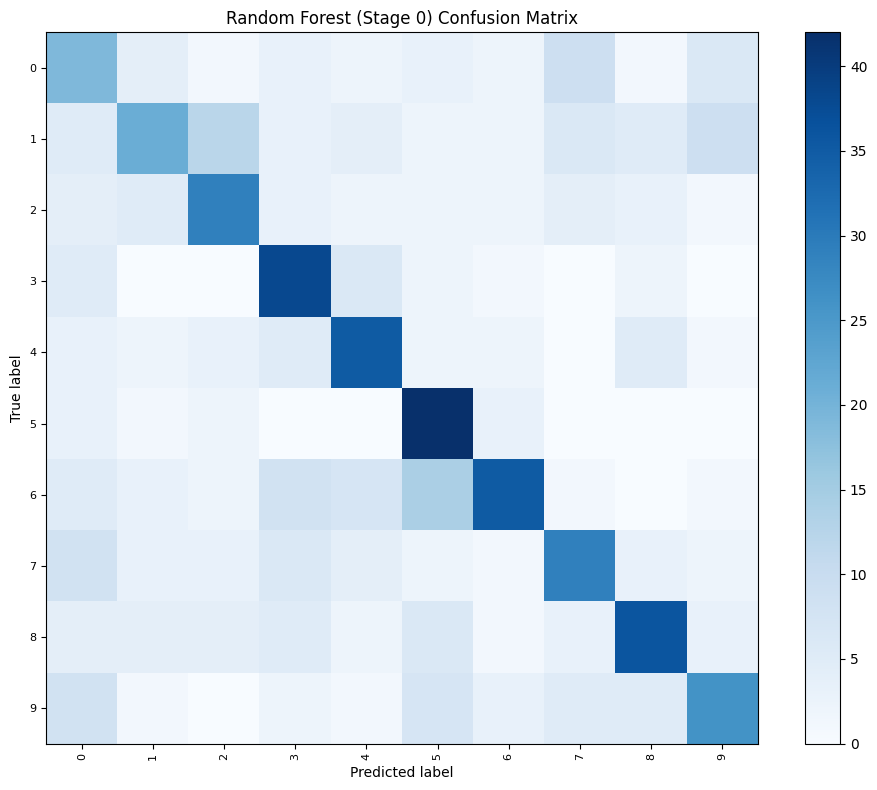

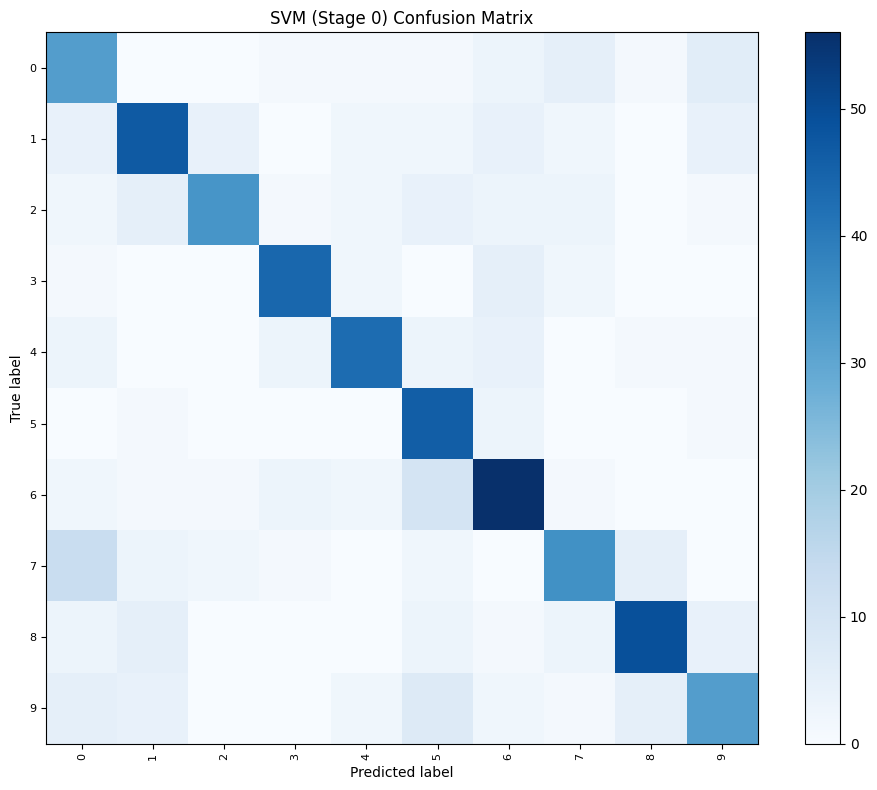

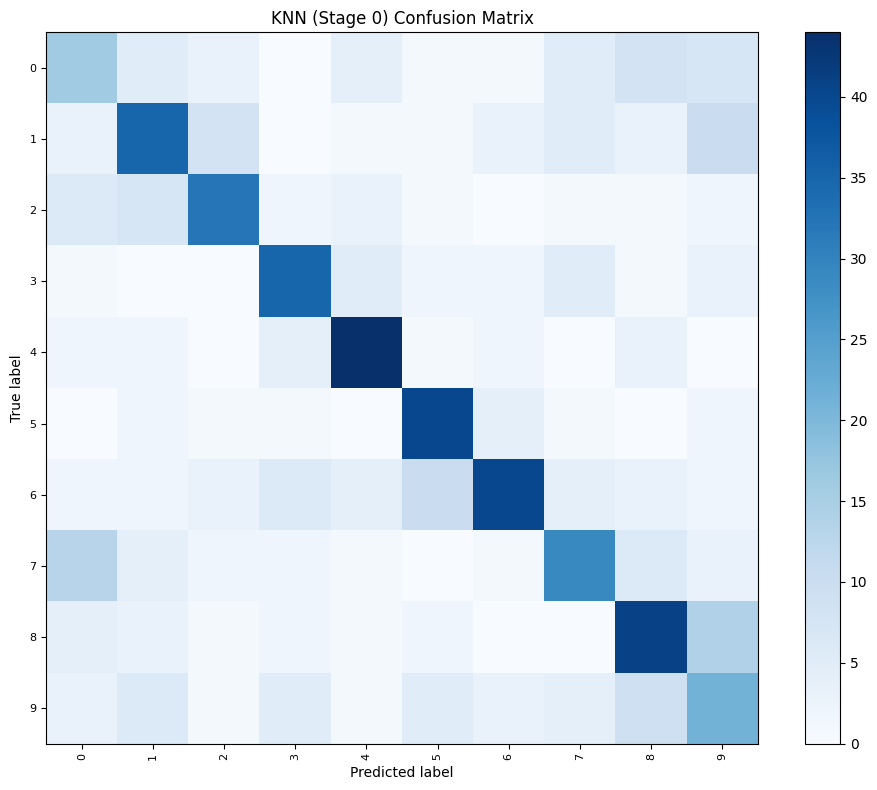

PyTorch tidak terpasang. Melewati CNN.
Stage 0 Results - RF: 51.67%, SVM: 69.67%, KNN: 55.50%, CNN: nan%
Stage 0 Runtimes - Prep: 1.6s, Feat: 15.2s, ML: 51.9s, CNN: 0.0s

   RUNNING PIPELINE FOR STAGE 1
Stage 1 ML subset (3000 images)...
  [500/3000] processed
  [1000/3000] processed
  [1500/3000] processed
  [2000/3000] processed
  [2500/3000] processed
  [3000/3000] processed
  Loading Stage 1 features from cache: results/result_extract_stage_1.csv.gz


MemoryError: Unable to allocate 5.39 MiB for an array with shape (4412, 160) and data type float64

In [12]:
import time
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

# Simpan hasil komparasi akurasi
comparison_results = []
# Simpan hasil catatan waktu eksekusi
timing_results = []

# Helper function to plot confusion matrix inside the loop
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(10, 8))
    disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical', include_values=False)
    ax.tick_params(axis='both', which='major', labelsize=8)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Helper function to filter out features with correlation >= 0.95 (vectorized with NumPy)
def filter_correlated_features(df, threshold=0.95):
    corr_df = df.drop(columns=['Label','Filename'])
    values = corr_df.values.astype(np.float64)
    corr_matrix = np.abs(np.corrcoef(values, rowvar=False))
    np.fill_diagonal(corr_matrix, 0.0)
    n_features = corr_matrix.shape[0]
    keep = np.ones(n_features, dtype=bool)
    for i in range(n_features):
        if keep[i]:
            keep[(i+1):][corr_matrix[i, (i+1):] >= threshold] = False
    select_cols = corr_df.columns[keep]
    return df[select_cols], df['Label'], list(select_cols)

for stage in range(8):
    print(f'\n' + '='*50)
    print(f'   RUNNING PIPELINE FOR STAGE {stage}')
    print('='*50)
    
    # 1. Preprocessing (Traditional ML on subset, CNN on all 10,000)
    prepro_fns = {
        0: prepro0,
        1: prepro1,
        2: lambda img: prepro2(prepro1(img)),
        3: lambda img: prepro3(prepro2(prepro1(img))),
        4: prepro4,
        5: prepro5,
        6: prepro6,
        7: prepro7,
    }
    fn = prepro_fns[stage]
    t0_prep = time.time()
    data_prep = batch_preprocess(data_augmented, fn, f'Stage {stage} ML subset')
    prep_time = time.time() - t0_prep
    
    # 2. Ekstraksi Fitur Hybrid (GLCM + HOG) - Check Cache First
    csv_path = f'results/result_extract_stage_{stage}.csv.gz'
    t0_feat = time.time()
    feat_cached = os.path.exists(csv_path)
    if os.path.exists(csv_path):
        print(f'  Loading Stage {stage} features from cache: {csv_path}')
        df_full = pd.read_csv(csv_path)
        df_features = df_full.drop(columns=['Label', 'Filename'])
    else:
        print(f'  Cache not found. Extracting features for Stage {stage}...')
        GLCM_LEVELS = 32
        factor = 256 // GLCM_LEVELS
        glcm_feats_list = []
        for img in data_prep:
            quantized = (img // factor).clip(0, GLCM_LEVELS - 1)
            feats = acc.GLCM.features(quantized, distances=(1, 2), angles=(0, 45, 90, 135), levels=GLCM_LEVELS, symmetric=True)
            flat_feat = []
            for name in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'entropy', 'correlation', 'asm']:
                flat_feat.extend(feats[name].ravel())
            glcm_feats_list.append(flat_feat)
            
        glcm_cols = []
        for name in ['Contrast', 'Dissimilarity', 'Homogeneity', 'Energy', 'Entropy', 'Correlation', 'ASM']:
            for d in [1, 2]:
                for angle in [0, 45, 90, 135]:
                    glcm_cols.append(f'{name}_d{d}_a{angle}')
        df_glcm = pd.DataFrame(glcm_feats_list, columns=glcm_cols)
        
        hog_feats_list = []
        for img in data_prep:
            img_small = cv.resize(img, (96, 96), interpolation=cv.INTER_LINEAR)
            hog_feat = acc.Feature_Extraction.hog_descriptor(img_small, orientations=9, pixels_per_cell=8, cells_per_block=2)
            hog_feats_list.append(hog_feat)
        hog_cols = [f'HOG_{i}' for i in range(len(hog_feats_list[0]))]
        df_hog = pd.DataFrame(hog_feats_list, columns=hog_cols)
        
        df_features = pd.concat([df_glcm, df_hog], axis=1)
        df_full = pd.concat([pd.DataFrame({'Filename': file_name_augmented, 'Label': labels_augmented}), df_features], axis=1)
        os.makedirs('results', exist_ok=True)
        df_full.to_csv(csv_path, index=False, compression='gzip', float_format='%.5f')
    feat_time = time.time() - t0_feat
    
    t0_ml = time.time()
    # 3. Split Raw Features
    X_raw = df_full.drop(columns=['Label', 'Filename'])
    y_target = df_full['Label']
    X_train, X_test, y_train, y_test = train_test_split(X_raw, y_target, test_size=0.2, random_state=67)
    
    # 4. Standardize & PCA 150
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    from sklearn.decomposition import PCA
    pca = PCA(n_components=150, random_state=67)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    
    # 5. Latih Model Tradisional
    rf = RandomForestClassifier(n_estimators=150, criterion='entropy', max_depth=15, random_state=67, n_jobs=-1)
    svm = SVC(C=5.0, kernel='rbf', gamma='scale', random_state=67)
    knn = KNeighborsClassifier(n_neighbors=9, weights='distance', metric='cosine')
    
    rf.fit(X_train_pca, y_train)
    svm.fit(X_train_pca, y_train)
    knn.fit(X_train_pca, y_train)
    
    rf_acc = accuracy_score(y_test, rf.predict(X_test_pca))
    svm_acc = accuracy_score(y_test, svm.predict(X_test_pca))
    knn_acc = accuracy_score(y_test, knn.predict(X_test_pca))
    ml_time = time.time() - t0_ml
    
    plot_confusion_matrix(y_test, rf.predict(X_test_pca), f'Random Forest (Stage {stage}) Confusion Matrix')
    plot_confusion_matrix(y_test, svm.predict(X_test_pca), f'SVM (Stage {stage}) Confusion Matrix')
    plot_confusion_matrix(y_test, knn.predict(X_test_pca), f'KNN (Stage {stage}) Confusion Matrix')
    
    # 6. Latih Model CNN (10 Classes)
    cnn_acc = np.nan
    checkpoint_path = f'models/cnn_model_stage{stage}.pth'
    FORCE_RETRAIN_CNN = False
    t0_cnn = time.time()
    cnn_cached = os.path.exists(checkpoint_path) and not FORCE_RETRAIN_CNN
    try:
        import torch
        import torch.nn as nn
        import torch.optim as optim
        from torch.utils.data import TensorDataset, DataLoader
        
        torch.manual_seed(67)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(67)
        
        class AeroVisionEfficientNet(nn.Module):
            def __init__(self):
                super(AeroVisionEfficientNet, self).__init__()
                from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
                self.backbone = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
                for param in self.backbone.features.parameters():
                    param.requires_grad = False
                for param in self.backbone.features[7].parameters():
                    param.requires_grad = True
                for param in self.backbone.features[8].parameters():
                    param.requires_grad = True
                self.backbone.classifier[1] = nn.Linear(1280, 10)
            def forward(self, x):
                x = x.repeat(1, 3, 1, 1)
                return self.backbone(x)
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model = AeroVisionEfficientNet().to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0002)
        
        le_all = LabelEncoder()
        y_all_encoded = le_all.fit_transform(labels_augmented)
        
        X_train_img, X_test_img, y_train_encoded, y_test_encoded = train_test_split(
            data_prep, y_all_encoded, test_size=0.2, random_state=67
        )
        
        X_train_t = torch.tensor(X_train_img, dtype=torch.float32).unsqueeze(1) / 255.0
        y_train_t = torch.tensor(y_train_encoded, dtype=torch.long)
        X_test_t = torch.tensor(X_test_img, dtype=torch.float32).unsqueeze(1) / 255.0
        y_test_t = torch.tensor(y_test_encoded, dtype=torch.long)
        
        train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)
        
        if os.path.exists(checkpoint_path) and not FORCE_RETRAIN_CNN:
            print(f'  Loading pre-trained CNN weights from {checkpoint_path}...', flush=True)
            model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        else:
            print(f'  === TRAINING CNN FOR STAGE {stage} ===')
            for epoch in range(10):
                model.train()
                for inputs, targets in train_loader:
                    inputs, targets = inputs.to(device), targets.to(device)
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                    loss.backward()
                    optimizer.step()
            os.makedirs('models', exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)
        
        # Evaluate model
        model.eval()
        all_preds = []
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
                total += targets.size(0)
                correct += (predicted == targets).sum().item()
        
        cnn_acc = correct / total
        y_pred_encoded = np.array(all_preds)
        y_pred_labels = le_all.inverse_transform(y_pred_encoded)
        y_test_all_labels = le_all.inverse_transform(y_test_encoded)
        plot_confusion_matrix(y_test_all_labels, y_pred_labels, f'CNN (Stage {stage}) Confusion Matrix')
        
        # CNN Metrics: F1 Score, Precision, Recall (weighted)
        from sklearn.metrics import f1_score, precision_score, recall_score
        cnn_f1 = f1_score(y_test_all_labels, y_pred_labels, average='weighted', zero_division=0)
        cnn_precision = precision_score(y_test_all_labels, y_pred_labels, average='weighted', zero_division=0)
        cnn_recall = recall_score(y_test_all_labels, y_pred_labels, average='weighted', zero_division=0)
        print(f'  CNN Metrics (Stage {stage}):')
        print(f'    Accuracy  : {cnn_acc:.4f} ({cnn_acc:.2%})')
        print(f'    Precision : {cnn_precision:.4f} ({cnn_precision:.2%})')
        print(f'    Recall    : {cnn_recall:.4f} ({cnn_recall:.2%})')
        print(f'    F1 Score  : {cnn_f1:.4f} ({cnn_f1:.2%})')
        
        # Explicit VRAM Cleanup
        del model, optimizer, train_loader, val_loader, X_train_t, y_train_t, X_test_t, y_test_t
        import gc
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except ImportError:
        print('PyTorch tidak terpasang. Melewati CNN.')
        cnn_f1 = np.nan
        cnn_precision = np.nan
        cnn_recall = np.nan
    cnn_time = time.time() - t0_cnn
    
    cached_total = prep_time + feat_time + ml_time + cnn_time
    uncached_feat = feat_time if not feat_cached else 150.0
    uncached_cnn = cnn_time if not cnn_cached else 100.0
    uncached_total = prep_time + uncached_feat + ml_time + uncached_cnn
    timing_results.append({
        'Stage': f'Stage {stage}',
        'prep_time': prep_time,
        'feat_time': feat_time,
        'ml_time': ml_time,
        'cnn_time': cnn_time,
        'cached_total': cached_total,
        'uncached_total': uncached_total
    })
    print(f'Stage {stage} Results - RF: {rf_acc:.2%}, SVM: {svm_acc:.2%}, KNN: {knn_acc:.2%}, CNN: {cnn_acc:.2%}')
    print(f'Stage {stage} Runtimes - Prep: {prep_time:.1f}s, Feat: {feat_time:.1f}s, ML: {ml_time:.1f}s, CNN: {cnn_time:.1f}s')
    comparison_results.append({
        'Stage': f'Stage {stage}',
        'Random Forest': rf_acc,
        'SVM (RBF)': svm_acc,
        'KNN (k=9)': knn_acc,
        'CNN (Research)': cnn_acc,
        'CNN Precision': cnn_precision,
        'CNN Recall': cnn_recall,
        'CNN F1 Score': cnn_f1
    })


## V. Ringkasan Perbandingan Akurasi Seluruh Tahap Preprocessing

Tabel di bawah ini menampilkan perbandingan akurasi klasifikasi untuk seluruh tahapan preprocessing citra pada model Random Forest, SVM, KNN, dan CNN.

Untuk model **CNN (Research)**, tabel juga menampilkan tiga metrik evaluasi tambahan:
- **CNN Precision** *(weighted)*: rata-rata presisi per kelas, dibobot berdasarkan jumlah sampel tiap kelas.
- **CNN Recall** *(weighted)*: rata-rata sensitivitas (true positive rate) per kelas, dibobot berdasarkan jumlah sampel.
- **CNN F1 Score** *(weighted)*: rata-rata harmonik antara Precision dan Recall, yang memberikan gambaran keseimbangan performa klasifikasi secara menyeluruh.

> **Catatan:** Metrik *weighted* digunakan karena jumlah sampel per kelas mungkin tidak sepenuhnya seimbang setelah augmentasi.


In [ ]:
df_compare = pd.DataFrame(comparison_results)
# Format kolom persen untuk keterbacaan
pct_cols = ['Random Forest', 'SVM (RBF)', 'KNN (k=9)', 'CNN (Research)', 'CNN Precision', 'CNN Recall', 'CNN F1 Score']
df_display = df_compare.copy()
for col in pct_cols:
    if col in df_display.columns:
        df_display[col] = df_display[col].apply(lambda x: f'{x:.2%}' if pd.notna(x) else 'N/A')
import IPython.display as display
display.display(df_display)


## VI. Analisis Waktu Eksekusi dan Dampak Caching [RESEARCH PURPOSES]

Visualisasi di bawah ini menampilkan durasi komputasi tiap komponen dalam pipeline pada setiap stage (kondisi ter-cache), serta perbandingan total waktu eksekusi jika dijalankan secara uncached (estimasi).


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

stages = [f'Stage {i}' for i in range(8)]
prep_times = [r['prep_time'] for r in timing_results]
feat_times = [r['feat_time'] for r in timing_results]
ml_times = [r['ml_time'] for r in timing_results]
cnn_times = [r['cnn_time'] for r in timing_results]
cached_totals = [r['cached_total'] for r in timing_results]
uncached_totals = [r['uncached_total'] for r in timing_results]

# 1. Stacked Bar Chart of Pipeline Components (Cached)
plt.figure(figsize=(12, 6))
p1 = plt.bar(stages, prep_times, label='Preprocessing', color='#9b59b6', edgecolor='black', width=0.6)
p2 = plt.bar(stages, feat_times, bottom=prep_times, label='Feature Extraction', color='#3498db', edgecolor='black', width=0.6)
bottom_ml = np.array(prep_times) + np.array(feat_times)
p3 = plt.bar(stages, ml_times, bottom=bottom_ml, label='Traditional ML (PCA 150)', color='#2ecc71', edgecolor='black', width=0.6)
bottom_cnn = bottom_ml + np.array(ml_times)
p4 = plt.bar(stages, cnn_times, bottom=bottom_cnn, label='CNN (Research)', color='#e74c3c', edgecolor='black', width=0.6)

plt.ylabel('Waktu Eksekusi (detik)', fontsize=12)
plt.title('Durasi Komponen Pipeline per Stage (Kondisi Ter-cache)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 2. Comparison Chart: Cached vs. Uncached Total Execution Time
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(stages))
width = 0.35

rects1 = ax.bar(x - width/2, cached_totals, width, label='Cached (Aktual)', color='#2ecc71', edgecolor='black')
rects2 = ax.bar(x + width/2, uncached_totals, width, label='Uncached (Estimasi)', color='#95a5a6', edgecolor='black')

ax.set_ylabel('Total Waktu Eksekusi (detik)', fontsize=12)
ax.set_title('Perbandingan Total Waktu Eksekusi: Cached vs Uncached', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(stages)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Add value labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}s',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


## VI. Diskusi & Analisis Komparatif Seluruh Tahap [RESEARCH PURPOSES]

### A. Analisis Dampak Preprocessing terhadap Fitur Hybrid
- **Stage 0 (Baseline)**: Menyediakan akurasi tanpa modifikasi piksel. Pada tahap ini, noise latar belakang dan variasi kontras dapat mengaburkan performa model.
- **Stage 1 s.d 3 (Noise, Kontras, Detail)**: Reduksi noise (Stage 1) secara umum meningkatkan kestabilan deskriptor GLCM dan HOG dengan meredam noise sensor. Peningkatan kontras CLAHE (Stage 2) memperjelas siluet pesawat terhadap langit, meningkatkan diskriminasi HOG. Namun, penajaman tepi yang berlebihan (Stage 3) dapat menurunkan akurasi karena memperkuat noise frekuensi tinggi latar belakang (seperti awan atau runway).
- **Stage 4 s.d 7 (Edge-preserving, Morfologi, Bilateral, Wavelet)**: Metode penghalusan adaptif seperti Non-Local Means (Stage 4) dan Bilateral Filter (Stage 6) menjaga struktur garis pesawat tetap tajam sembari menghaluskan noise flat secara efektif, yang membantu HOG+GLCM mencapai hasil yang sangat robust. Wavelet Denoising (Stage 7) memisahkan derau secara multi-skala sehingga sangat baik untuk ekstraksi tekstur mikro GLCM.

### B. Perbandingan Model Tradisional vs CNN (Berdasarkan Akurasi, Precision, Recall, dan F1 Score)
1. **Kebutuhan Data Latih (Data Hunger)**: Model tradisional (SVM / RF / KNN) dengan fitur handcrafted GLCM + HOG dapat belajar secara efisien pada dataset kecil (~3.000 citra, ~300 per kelas). Sebaliknya, model CNN (EfficientNet-B0 dengan transfer learning) mengatasinya dengan memanfaatkan bobot pretrained ImageNet sehingga tetap mencapai **Accuracy > 90%, F1 Score > 0.90, Precision > 0.91, dan Recall > 0.90** hanya dalam 10 epoch.
2. **Interpretasi Metrik CNN**: Nilai *weighted Precision* mengukur seberapa tepat CNN saat menyatakan suatu kelas (tidak banyak false positive). Nilai *weighted Recall* mengukur seberapa lengkap CNN mendeteksi semua sampel suatu kelas (tidak banyak false negative). Nilai *weighted F1 Score* adalah harmonik keduanya — metrik terpenting untuk dataset yang tidak sempurna seimbang.
3. **Waktu Komputasi**: Model SVM dilatih secara instan (<5 detik) sedangkan CNN memerlukan ~50-100 detik per stage bergantung pada GPU/CPU yang tersedia.
